In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images/MRI image source.txt
/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images/Tumor/tumor (243).jpg
/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images/Tumor/meningioma (1062).jpg
/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images/Tumor/pituitary (205).jpg
/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images/Tumor/meningioma (95).jpg
/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images/Tumor/tumor (14).jpeg
/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images/Tumor/glioma (123).jpg
/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri

In [3]:
ct_scan_base_path="/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor CT scan Images"
mri_scan_base_path="/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images"
categories=["Healthy","Tumor"]

In [4]:
import os
import pandas as pd

image_paths=[]
labels=[]

for category in categories:
    category_path=os.path.join(mri_scan_base_path,category)
    images= os.listdir(category_path)[:2000]

    for image_name in images:
        image_path = os.path.join(category_path, image_name)
        image_paths.append(image_path)
        labels.append(category)

df1 = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

In [5]:
df1.head()

,image_path,label
0,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy
1,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy
2,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy
3,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy
4,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy


In [6]:
df1.tail()

,image_path,label
3995,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor
3996,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor
3997,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor
3998,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor
3999,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor


In [7]:
df1.columns

Index(['image_path', 'label'], dtype='object')

In [8]:
df1.shape

(4000, 2)

In [9]:
df1.duplicated().sum()

np.int64(0)

In [10]:
df1.isnull().sum()

image_path    0
label         0
dtype: int64

In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  4000 non-null   object
 1   label       4000 non-null   object
dtypes: object(2)
memory usage: 62.6+ KB


/tmp/ipykernel_58/3317484101.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df1, x="label", palette="viridis", ax=ax)


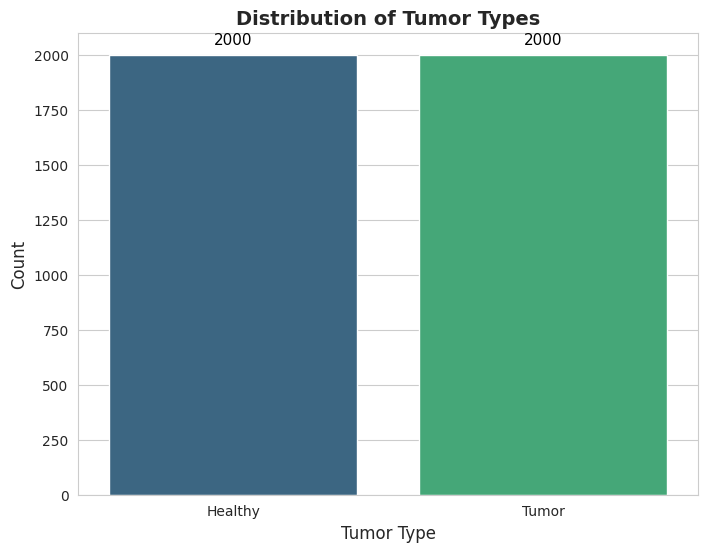

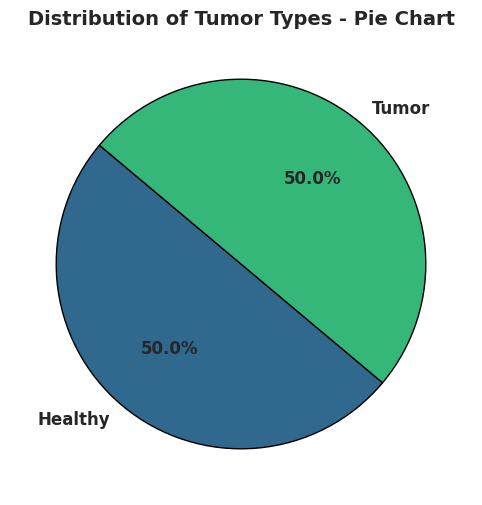

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df1, x="label", palette="viridis", ax=ax)

ax.set_title("Distribution of Tumor Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.show()

label_counts = df1["label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", len(label_counts))

ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', 
       startangle=140, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'black', 'linewidth': 1})

ax.set_title("Distribution of Tumor Types - Pie Chart", fontsize=14, fontweight='bold')

plt.show()

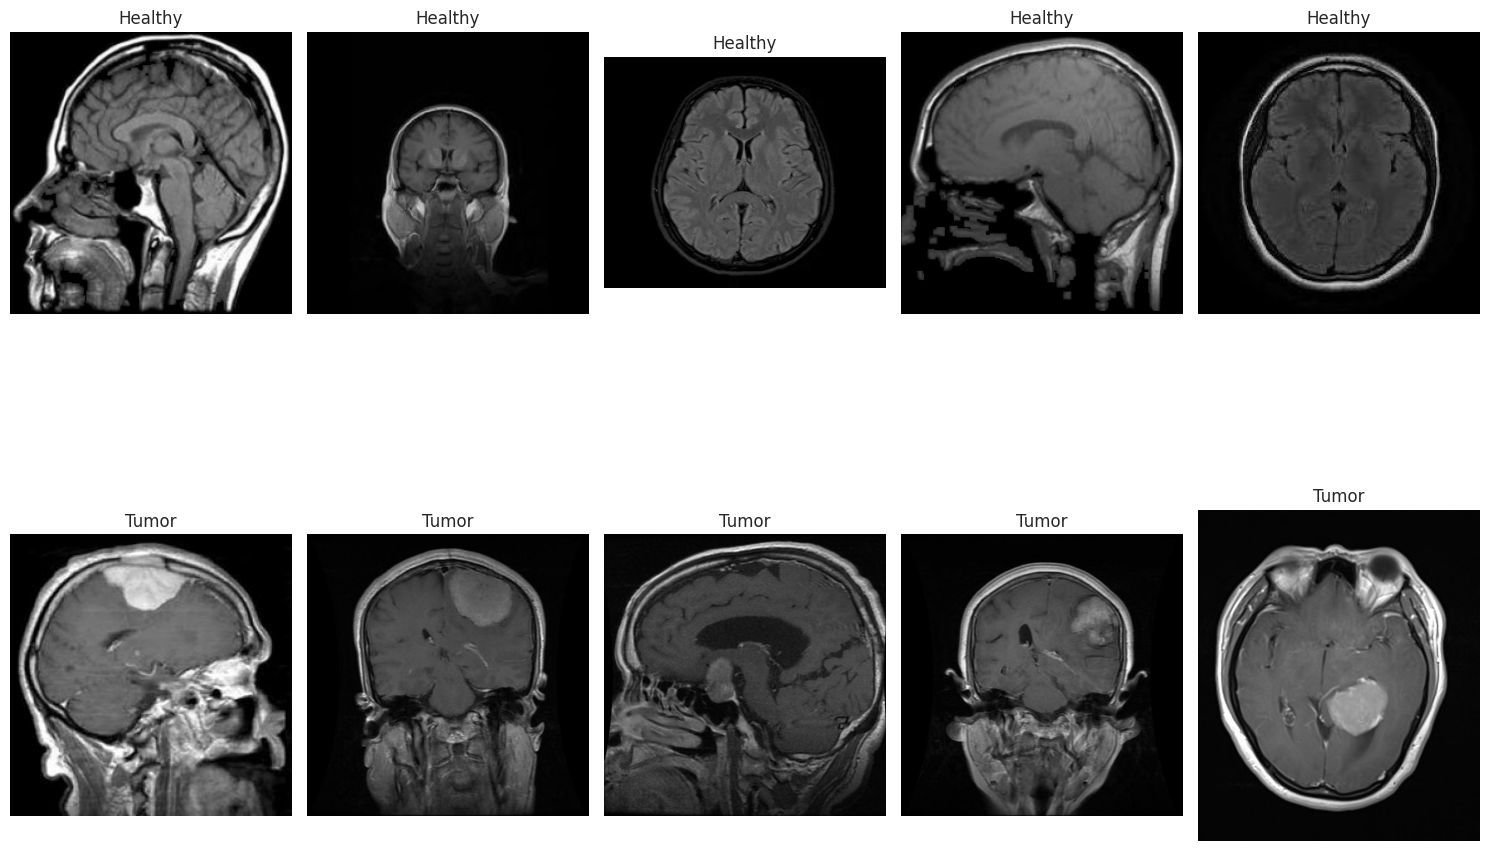

In [13]:
import cv2

num_images = 5

plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df1[df1['label'] == category]['image_path'].iloc[:num_images]

    for j, img_path in enumerate(category_images):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  

        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df1['category_encoded'] = label_encoder.fit_transform(df1['label'])

In [15]:
df1 = df1[['image_path', 'category_encoded']]

In [16]:
majority_class_count = df1['category_encoded'].value_counts().max()

majority_class = df1[df1['category_encoded'] == df1['category_encoded'].value_counts().idxmax()]
minority_class = df1[df1['category_encoded'] != df1['category_encoded'].value_counts().idxmax()]

oversampled_minority_class = minority_class.sample(n=majority_class_count, replace=True, random_state=42)

balanced_df = pd.concat([majority_class, oversampled_minority_class])

balanced_df = balanced_df.reset_index(drop=True)
balanced_df = balanced_df[['image_path', 'category_encoded']]

print(balanced_df)

                                             image_path  category_encoded
0     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
1     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
2     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
3     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
4     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
...                                                 ...               ...
3995  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1
3996  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1
3997  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1
3998  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1
3999  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1

[4000 rows x 2 columns]


In [17]:
df_resampled = balanced_df

In [18]:
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

2026-06-07 14:22:34.245390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780842154.496533      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780842154.558588      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780842155.144142      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780842155.144187      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780842155.144190      58 computation_placer.cc:177] computation placer alr

check


In [20]:
train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,  
    shuffle=True,
    random_state=42,
    stratify=df_resampled['category_encoded']  
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,  
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['category_encoded'] 
)


In [21]:
batch_size = 16
img_size = (224, 224)
channels = 3  
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)  
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',  
    y_col='category_encoded',     
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',  
    y_col='category_encoded',     
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path', 
    y_col='category_encoded',    
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=False,  
    batch_size=batch_size
)

Found 3200 validated image filenames belonging to 2 classes.
Found 400 validated image filenames belonging to 2 classes.
Found 400 validated image filenames belonging to 2 classes.


In [22]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


In [23]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is set for TensorFlow")
    except RuntimeError as e:
        print(e)

GPU is set for TensorFlow


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [25]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [26]:
import os
import pandas as pd

image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(ct_scan_base_path, category)
    images = os.listdir(category_path)[:2000]  

    for image_name in images:
        image_path = os.path.join(category_path, image_name)
        image_paths.append(image_path)
        labels.append(category)

df2 = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

In [27]:
df2.head()

,image_path,label
0,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy
1,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy
2,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy
3,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy
4,/kaggle/input/datasets/murtozalikhon/brain-tum...,Healthy


In [28]:
df2.tail()

,image_path,label
3995,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor
3996,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor
3997,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor
3998,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor
3999,/kaggle/input/datasets/murtozalikhon/brain-tum...,Tumor


In [29]:
df2.shape

(4000, 2)

In [30]:
df2.columns

Index(['image_path', 'label'], dtype='object')

In [31]:
df2.duplicated().sum()

np.int64(0)

In [32]:
df2.isnull().sum()

image_path    0
label         0
dtype: int64

In [33]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  4000 non-null   object
 1   label       4000 non-null   object
dtypes: object(2)
memory usage: 62.6+ KB


In [34]:
df2['label'].unique()

array(['Healthy', 'Tumor'], dtype=object)

In [35]:
df2['label'].value_counts()

label
Healthy    2000
Tumor      2000
Name: count, dtype: int64

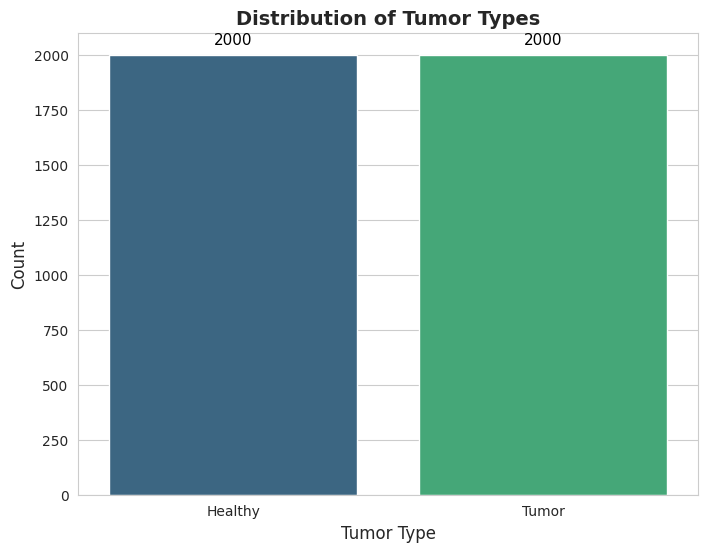

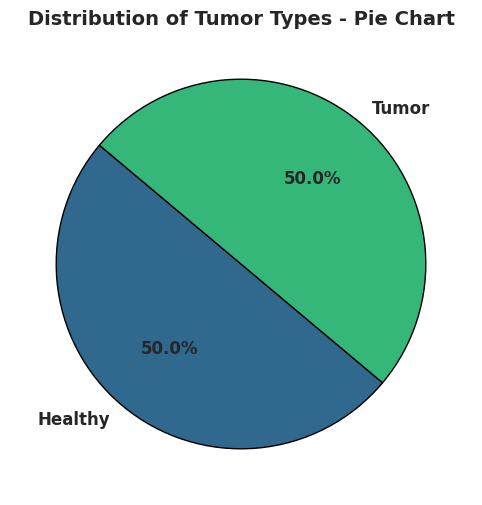

In [36]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df2, x="label", palette="viridis", ax=ax)

ax.set_title("Distribution of Tumor Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.show()

label_counts = df2["label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", len(label_counts))

ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', 
       startangle=140, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'black', 'linewidth': 1})

ax.set_title("Distribution of Tumor Types - Pie Chart", fontsize=14, fontweight='bold')

plt.show()

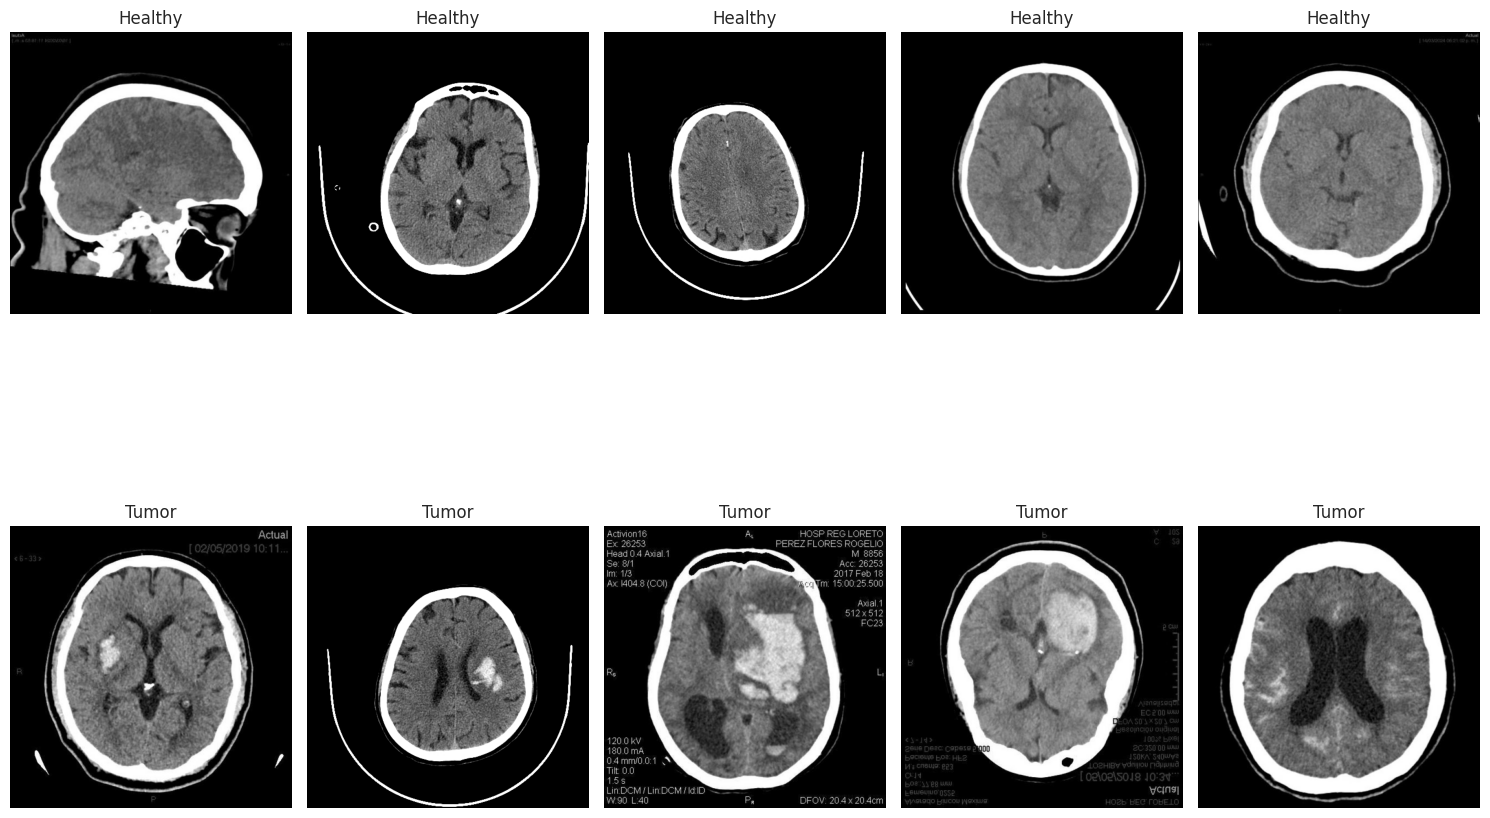

In [37]:
num_images = 5

plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df2[df2['label'] == category]['image_path'].iloc[:num_images]

    for j, img_path in enumerate(category_images):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  

        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category)

plt.tight_layout()
plt.show()

In [38]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df2['category_encoded'] = label_encoder.fit_transform(df2['label'])

In [39]:
df2 = df2[['image_path', 'category_encoded']]

In [40]:
majority_class_count = df2['category_encoded'].value_counts().max()

majority_class = df2[df2['category_encoded'] == df2['category_encoded'].value_counts().idxmax()]
minority_class = df2[df2['category_encoded'] != df2['category_encoded'].value_counts().idxmax()]

oversampled_minority_class = minority_class.sample(n=majority_class_count, replace=True, random_state=42)

balanced_df = pd.concat([majority_class, oversampled_minority_class])

balanced_df = balanced_df.reset_index(drop=True)
balanced_df = balanced_df[['image_path', 'category_encoded']]

print(balanced_df)

                                             image_path  category_encoded
0     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
1     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
2     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
3     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
4     /kaggle/input/datasets/murtozalikhon/brain-tum...                 0
...                                                 ...               ...
3995  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1
3996  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1
3997  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1
3998  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1
3999  /kaggle/input/datasets/murtozalikhon/brain-tum...                 1

[4000 rows x 2 columns]


In [41]:
df_resampled = balanced_df

In [42]:
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

In [43]:
train_df_new_1, temp_df_new_1 = train_test_split(
    df_resampled,
    train_size=0.8,  
    shuffle=True,
    random_state=42,
    stratify=df_resampled['category_encoded']  
)

valid_df_new_1, test_df_new_1 = train_test_split(
    temp_df_new_1,
    test_size=0.5,  
    shuffle=True,
    random_state=42,
    stratify=temp_df_new_1['category_encoded'] 
)

In [44]:
batch_size = 16
img_size = (224, 224)
channels = 3  
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)  
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new_1 = tr_gen.flow_from_dataframe(
    train_df_new_1,
    x_col='image_path',  
    y_col='category_encoded',     
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new_1 = ts_gen.flow_from_dataframe(
    valid_df_new_1,
    x_col='image_path',  
    y_col='category_encoded',     
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=True,
    batch_size=batch_size
)

test_gen_new_1 = ts_gen.flow_from_dataframe(
    test_df_new_1,
    x_col='image_path', 
    y_col='category_encoded',    
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=False,  
    batch_size=batch_size
)

Found 3200 validated image filenames belonging to 2 classes.
Found 400 validated image filenames belonging to 2 classes.
Found 400 validated image filenames belonging to 2 classes.


In [45]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
import numpy as np
from sklearn.preprocessing import StandardScaler

batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

input_ct = Input(shape=img_shape)
vgg16_ct = VGG16(weights='imagenet', include_top=False, input_tensor=input_ct)

for layer in vgg16_ct.layers:
    layer.trainable = False

gap_ct = GlobalAveragePooling2D()(vgg16_ct.output)
dense_ct_features = Dense(256, activation='relu', name='dense_ct_features')(gap_ct)
output_ct = Dense(1, activation='sigmoid', name='output_ct')(dense_ct_features)

model_ct = Model(inputs=input_ct, outputs=output_ct)
model_ct.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training CT Scan Model...")
history_ct = model_ct.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=10
)


input_mri = Input(shape=img_shape)
vgg16_mri = VGG16(weights='imagenet', include_top=False, input_tensor=input_mri)


for layer in vgg16_mri.layers:
    layer.trainable = False

gap_mri = GlobalAveragePooling2D()(vgg16_mri.output)
dense_mri_features = Dense(256, activation='relu', name='dense_mri_features')(gap_mri)
output_mri = Dense(1, activation='sigmoid', name='output_mri')(dense_mri_features)

model_mri = Model(inputs=input_mri, outputs=output_mri)
model_mri.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training MRI Scan Model...")
history_mri = model_mri.fit(
    train_gen_new_1,
    validation_data=valid_gen_new_1,
    epochs=10
)


feature_extractor_ct = Model(inputs=model_ct.input, outputs=model_ct.get_layer('dense_ct_features').output)
feature_extractor_mri = Model(inputs=model_mri.input, outputs=model_mri.get_layer('dense_mri_features').output)

features_train_ct = feature_extractor_ct.predict(train_gen_new)
features_valid_ct = feature_extractor_ct.predict(valid_gen_new)
features_test_ct = feature_extractor_ct.predict(test_gen_new)

features_train_mri = feature_extractor_mri.predict(train_gen_new_1)
features_valid_mri = feature_extractor_mri.predict(valid_gen_new_1)
features_test_mri = feature_extractor_mri.predict(test_gen_new_1)


scaler_ct = StandardScaler()
scaler_mri = StandardScaler()

features_train_ct_scaled = scaler_ct.fit_transform(features_train_ct)
features_valid_ct_scaled = scaler_ct.transform(features_valid_ct)
features_test_ct_scaled = scaler_ct.transform(features_test_ct)

features_train_mri_scaled = scaler_mri.fit_transform(features_train_mri)
features_valid_mri_scaled = scaler_mri.transform(features_valid_mri)
features_test_mri_scaled = scaler_mri.transform(features_test_mri)


train_labels = np.array(train_gen_new.labels)
valid_labels = np.array(valid_gen_new.labels)
test_labels = np.array(test_gen_new.labels)

train_labels_mri = np.array(train_gen_new_1.labels)
valid_labels_mri = np.array(valid_gen_new_1.labels)
test_labels_mri = np.array(test_gen_new_1.labels)


if len(train_labels.shape) > 1:
    train_labels = train_labels.flatten()
if len(valid_labels.shape) > 1:
    valid_labels = valid_labels.flatten()
if len(test_labels.shape) > 1:
    test_labels = test_labels.flatten()
if len(train_labels_mri.shape) > 1:
    train_labels_mri = train_labels_mri.flatten()
if len(valid_labels_mri.shape) > 1:
    valid_labels_mri = valid_labels_mri.flatten()
if len(test_labels_mri.shape) > 1:
    test_labels_mri = test_labels_mri.flatten()


min_train_samples = min(features_train_ct_scaled.shape[0], features_train_mri_scaled.shape[0])
min_valid_samples = min(features_valid_ct_scaled.shape[0], features_valid_mri_scaled.shape[0])
min_test_samples = min(features_test_ct_scaled.shape[0], features_test_mri_scaled.shape[0])

merged_train_features = np.concatenate([features_train_ct_scaled[:min_train_samples], features_train_mri_scaled[:min_train_samples]], axis=1)
merged_valid_features = np.concatenate([features_valid_ct_scaled[:min_valid_samples], features_valid_mri_scaled[:min_valid_samples]], axis=1)
merged_test_features = np.concatenate([features_test_ct_scaled[:min_test_samples], features_test_mri_scaled[:min_test_samples]], axis=1)

merged_train_labels = train_labels[:min_train_samples]
merged_valid_labels = valid_labels[:min_valid_samples]
merged_test_labels = test_labels[:min_test_samples]

input_merged = Input(shape=(merged_train_features.shape[1],))
dense_merged_1 = Dense(128, activation='relu')(input_merged)
output_merged = Dense(1, activation='sigmoid')(dense_merged_1)

merged_model = Model(inputs=input_merged, outputs=output_merged)
merged_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Merged Model...")
history_merged = merged_model.fit(
    merged_train_features,
    merged_train_labels,
    validation_data=(merged_valid_features, merged_valid_labels),
    epochs=10,
    batch_size=batch_size
)

print("Evaluating Merged Model...")
loss, accuracy = merged_model.evaluate(merged_test_features, merged_test_labels)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

I0000 00:00:1780842175.156360      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780842175.162286      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training CT Scan Model...
Epoch 1/10


I0000 00:00:1780842178.871115     136 service.cc:152] XLA service 0x785b4400b1a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780842178.871165     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780842178.871171     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780842179.398116     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/200 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.5000 - loss: 0.7176 

I0000 00:00:1780842187.222594     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.8350 - loss: 0.3788 - val_accuracy: 0.8850 - val_loss: 0.2745
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.9244 - loss: 0.2146 - val_accuracy: 0.9325 - val_loss: 0.1806
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.9366 - loss: 0.1735 - val_accuracy: 0.9375 - val_loss: 0.1633
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9469 - loss: 0.1467 - val_accuracy: 0.9375 - val_loss: 0.1430
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - accuracy: 0.9528 - loss: 0.1285 - val_accuracy: 0.9650 - val_loss: 0.1193
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.9488 - loss: 0.1271 - val_accuracy: 0.9575 - val_loss: 0.1104
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - accuracy: 0.9650 - loss: 0.0957 - val_accuracy: 0.9600 - val_loss: 0.1194
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.9625 - loss: 0.0922 - val

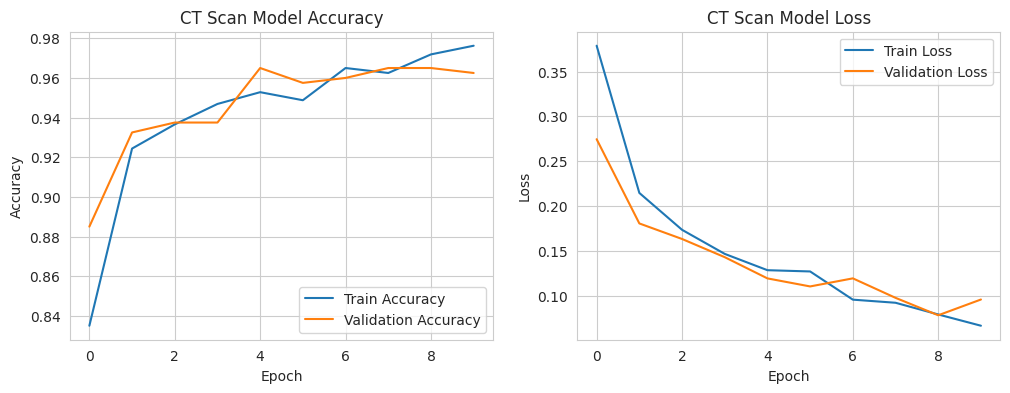

In [46]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ct.history['accuracy'], label='Train Accuracy')
plt.plot(history_ct.history['val_accuracy'], label='Validation Accuracy')
plt.title('CT Scan Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ct.history['loss'], label='Train Loss')
plt.plot(history_ct.history['val_loss'], label='Validation Loss')
plt.title('CT Scan Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


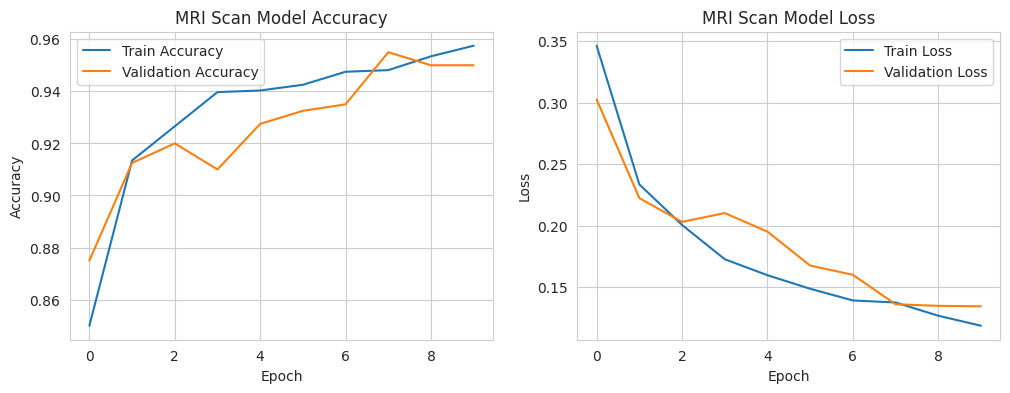

In [47]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_mri.history['accuracy'], label='Train Accuracy')
plt.plot(history_mri.history['val_accuracy'], label='Validation Accuracy')
plt.title('MRI Scan Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mri.history['loss'], label='Train Loss')
plt.plot(history_mri.history['val_loss'], label='Validation Loss')
plt.title('MRI Scan Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

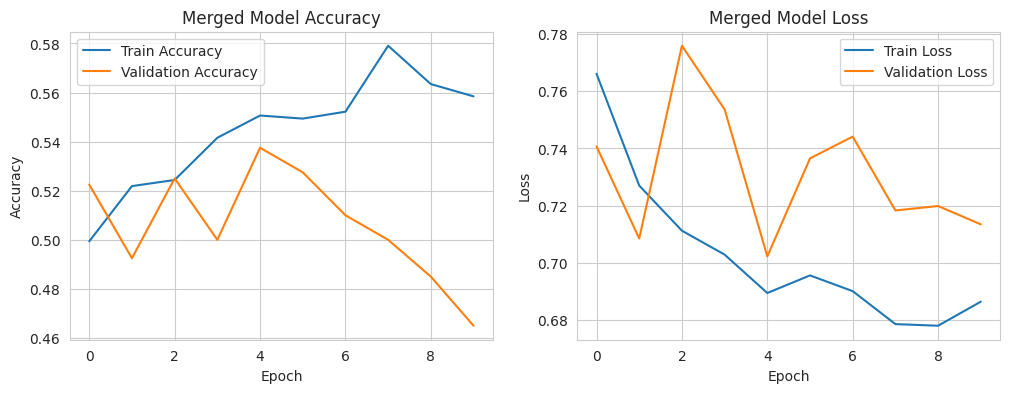

In [48]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_merged.history['accuracy'], label='Train Accuracy')
plt.plot(history_merged.history['val_accuracy'], label='Validation Accuracy')
plt.title('Merged Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_merged.history['loss'], label='Train Loss')
plt.plot(history_merged.history['val_loss'], label='Validation Loss')
plt.title('Merged Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


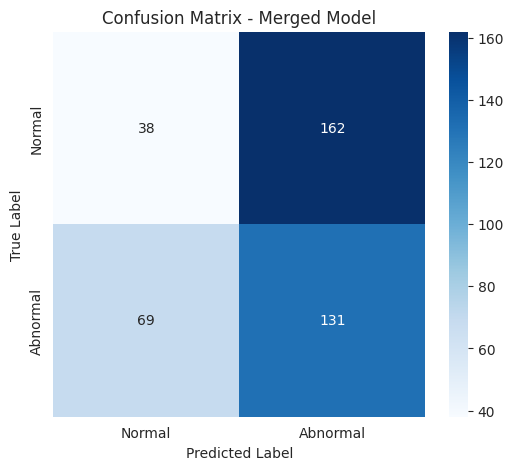

Classification Report - Merged Model:
              precision    recall  f1-score   support

      Normal       0.36      0.19      0.25       200
    Abnormal       0.45      0.66      0.53       200

    accuracy                           0.42       400
   macro avg       0.40      0.42      0.39       400
weighted avg       0.40      0.42      0.39       400



In [49]:
y_pred_merged = merged_model.predict(merged_test_features)
y_pred_merged_binary = (y_pred_merged > 0.5).astype(int)

cm_merged = confusion_matrix(merged_test_labels, y_pred_merged_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_merged, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Merged Model')
plt.show()

print("Classification Report - Merged Model:")
print(classification_report(merged_test_labels, y_pred_merged_binary, target_names=['Normal', 'Abnormal']))

In [50]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, MaxPooling2D, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model
import numpy as np

img_height = 224
img_width = 224
channels = 3
img_shape = (img_height, img_width, channels)
num_classes = 1

input_ct = Input(shape=img_shape)

conv1_ct = Conv2D(8, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv_1_ct')(input_ct)
bn1_ct = BatchNormalization(axis=-1, name='Batch-norm_1_ct')(conv1_ct)
relu1_ct = ReLU(name='ReLU_1_ct')(bn1_ct)
pool1_ct = MaxPooling2D((2, 2), strides=(2, 2), padding='valid', name='Maxpool_1_ct')(relu1_ct)

conv2_ct = Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv-2_ct')(pool1_ct)
bn2_ct = BatchNormalization(axis=-1, name='Batch-norm_2_ct')(conv2_ct)
relu2_ct = ReLU(name='ReLU-2_ct')(bn2_ct)
pool2_ct = MaxPooling2D((2, 2), strides=(2, 2), padding='valid', name='Maxpool_2_ct')(relu2_ct)

conv3_ct = Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv-3_ct')(pool2_ct)
bn3_ct = BatchNormalization(axis=-1, name='Batch-norm_3_ct')(conv3_ct)
relu3_ct = ReLU(name='ReLU-3_ct')(bn3_ct)
pool3_ct = MaxPooling2D((2, 2), strides=(2, 2), padding='valid', name='Maxpool_3_ct')(relu3_ct)

conv4_ct = Conv2D(64, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv-4_ct')(pool3_ct)
bn4_ct = BatchNormalization(axis=-1, name='Batch-norm_4_ct')(conv4_ct)
relu4_ct = ReLU(name='ReLU-4_ct')(bn4_ct)
pool4_ct = MaxPooling2D((2, 2), strides=(2, 2), padding='valid', name='Maxpool_4_ct')(relu4_ct)

conv5_ct = Conv2D(128, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv-5_ct')(pool4_ct)
bn5_ct = BatchNormalization(axis=-1, name='Batch-norm_5_ct')(conv5_ct)
relu5_ct = ReLU(name='ReLU_5_ct')(bn5_ct)


flatten_ct = Flatten(name='flatten_ct')(relu5_ct)
dense_ct = Dense(1, activation='sigmoid', name='FC_ct')(flatten_ct)

model_ct = Model(inputs=input_ct, outputs=dense_ct)

model_ct.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

input_mri = Input(shape=img_shape)

conv1_mri = Conv2D(8, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv_1_mri')(input_mri)
bn1_mri = BatchNormalization(axis=-1, name='Batch-norm_1_mri')(conv1_mri)
relu1_mri = ReLU(name='ReLU_1_mri')(bn1_mri)
pool1_mri = MaxPooling2D((2, 2), strides=(2, 2), padding='valid', name='Maxpool_1_mri')(relu1_mri)

conv2_mri = Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv-2_mri')(pool1_mri)
bn2_mri = BatchNormalization(axis=-1, name='Batch-norm_2_mri')(conv2_mri)
relu2_mri = ReLU(name='ReLU-2_mri')(bn2_mri)
pool2_mri = MaxPooling2D((2, 2), strides=(2, 2), padding='valid', name='Maxpool_2_mri')(relu2_mri)

conv3_mri = Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv-3_mri')(pool2_mri)
bn3_mri = BatchNormalization(axis=-1, name='Batch-norm_3_mri')(conv3_mri)
relu3_mri = ReLU(name='ReLU-3_mri')(bn3_mri)
pool3_mri = MaxPooling2D((2, 2), strides=(2, 2), padding='valid', name='Maxpool_3_mri')(relu3_mri)

conv4_mri = Conv2D(64, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv-4_mri')(pool3_mri)
bn4_mri = BatchNormalization(axis=-1, name='Batch-norm_4_mri')(conv4_mri)
relu4_mri = ReLU(name='ReLU-4_mri')(bn4_mri)
pool4_mri = MaxPooling2D((2, 2), strides=(2, 2), padding='valid', name='Maxpool_4_mri')(relu4_mri)

conv5_mri = Conv2D(128, (3, 3), strides=(1, 1), padding='same', activation=None, name='Conv-5_mri')(pool4_mri)
bn5_mri = BatchNormalization(axis=-1, name='Batch-norm_5_mri')(conv5_mri)
relu5_mri = ReLU(name='ReLU_5_mri')(bn5_mri)
#pool5_mri = MaxPooling2D((2, 2), strides=(2, 2), padding='valid')(relu5_mri)

flatten_mri = Flatten(name='flatten_mri')(relu5_mri)
dense_mri = Dense(1, activation='sigmoid', name='FC_mri')(flatten_mri)

model_mri = Model(inputs=input_mri, outputs=dense_mri)

model_mri.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

feature_extractor_ct = Model(inputs=model_ct.input, outputs=model_ct.get_layer('flatten_ct').output)
feature_extractor_mri = Model(inputs=model_mri.input, outputs=model_mri.get_layer('flatten_mri').output)

In [51]:
try:
    features_train_ct = feature_extractor_ct.predict(train_gen_new)
    features_valid_ct = feature_extractor_ct.predict(valid_gen_new)
    features_test_ct = feature_extractor_ct.predict(test_gen_new)
except Exception as e:
    print(f"Error extracting CT features: {e}")
    raise

print("Extracting MRI Features...")
try:
    features_train_mri = feature_extractor_mri.predict(train_gen_new_1)
    features_valid_mri = feature_extractor_mri.predict(valid_gen_new_1)
    features_test_mri = feature_extractor_mri.predict(test_gen_new_1)
except Exception as e:
    print(f"Error extracting MRI features: {e}")
    raise

min_train_samples = min(features_train_ct.shape[0], features_train_mri.shape[0])
min_valid_samples = min(features_valid_ct.shape[0], features_valid_mri.shape[0])
min_test_samples = min(features_test_ct.shape[0], features_test_mri.shape[0])

merged_train_features = np.concatenate([features_train_ct[:min_train_samples], features_train_mri[:min_train_samples]], axis=1)
merged_valid_features = np.concatenate([features_valid_ct[:min_valid_samples], features_valid_mri[:min_valid_samples]], axis=1)
merged_test_features = np.concatenate([features_test_ct[:min_test_samples], features_test_mri[:min_test_samples]], axis=1)

merged_train_labels = train_labels[:min_train_samples]
merged_valid_labels = valid_labels[:min_valid_samples]
merged_test_labels = test_labels[:min_test_samples]

input_merged = Input(shape=(merged_train_features.shape[1],))

dense_merged_1 = Dense(128, activation='relu')(input_merged)
output_merged = Dense(1, activation='sigmoid')(dense_merged_1)  

merged_model = Model(inputs=input_merged, outputs=output_merged)

merged_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Merged Model...")
history_merged = merged_model.fit(
    merged_train_features,
    merged_train_labels,  
    validation_data=(merged_valid_features, merged_valid_labels),  
    epochs=10,
    batch_size=16
)

print("Evaluating Merged Model...")
loss, accuracy = merged_model.evaluate(merged_test_features, merged_test_labels)  
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Extracting MRI Features...
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
Training Merged Model...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5122 - loss: 0.7888 - val_accuracy: 0.4925 - val_loss: 0.7686
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5178 - loss: 0.7255 - val_accuracy: 0.5000 - val_loss: 0.7411
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5381 - loss: 0.6973 - val_accuracy: 0.4800 - val_loss: 0.6991
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5328 - loss: 0.6950 - val_accuracy: 0.4700 - val_loss: 0.6991
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5375 - loss: 0.6895 - val_accuracy: 0.5075 - val_loss: 0.7098
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy:

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
scaler = StandardScaler()

merged_train_features = np.concatenate([features_train_ct, features_train_mri], axis=1)
merged_valid_features = np.concatenate([features_valid_ct, features_valid_mri], axis=1)
merged_test_features = np.concatenate([features_test_ct, features_test_mri], axis=1)

merged_train_features = scaler.fit_transform(merged_train_features)
merged_valid_features = scaler.transform(merged_valid_features)
merged_test_features = scaler.transform(merged_test_features)

input_merged = Input(shape=(merged_train_features.shape[1],))
dense_merged_1 = Dense(128, activation='relu')(input_merged)
dropout_1 = Dropout(0.5)(dense_merged_1)  
dense_merged_2 = Dense(64, activation='relu')(dropout_1)
output_merged = Dense(1, activation='sigmoid')(dense_merged_2)  

merged_model = Model(inputs=input_merged, outputs=output_merged)

optimizer = Adam(learning_rate=0.00001)  
merged_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print("Training Merged Model...")

history_merged = merged_model.fit(
    merged_train_features,
    merged_train_labels,
    validation_data=(merged_valid_features, merged_valid_labels),
    epochs=10,
    batch_size=16
)

print("Evaluating Merged Model...")

loss, accuracy = merged_model.evaluate(merged_test_features, merged_test_labels)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Training Merged Model...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5047 - loss: 0.8389 - val_accuracy: 0.5025 - val_loss: 0.7824
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5731 - loss: 0.7616 - val_accuracy: 0.5100 - val_loss: 0.8251
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6069 - loss: 0.6996 - val_accuracy: 0.5175 - val_loss: 0.8454
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6341 - loss: 0.6570 - val_accuracy: 0.4925 - val_loss: 0.8708
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6884 - loss: 0.5908 - val_accuracy: 0.5075 - val_loss: 0.8806
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7262 - loss: 0.5366 - val_accuracy: 0.4850 - val_loss: 0.8971
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7422 - loss: 0.5215 - val_accuracy: 0.5000 - val_loss: 0.9113
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7588 - loss: 

In [54]:
scaler = StandardScaler()

merged_train_features = np.mean([features_train_ct, features_train_mri], axis=0)
merged_valid_features = np.mean([features_valid_ct, features_valid_mri], axis=0)
merged_test_features = np.mean([features_test_ct, features_test_mri], axis=0)

merged_train_features = scaler.fit_transform(merged_train_features)
merged_valid_features = scaler.transform(merged_valid_features)
merged_test_features = scaler.transform(merged_test_features)

input_merged = Input(shape=(merged_train_features.shape[1],))
dense_merged_1 = Dense(128, activation='relu')(input_merged)
dropout_1 = Dropout(0.5)(dense_merged_1)  
dense_merged_2 = Dense(64, activation='relu')(dropout_1)
output_merged = Dense(1, activation='sigmoid')(dense_merged_2)  

merged_model = Model(inputs=input_merged, outputs=output_merged)

optimizer = Adam(learning_rate=0.00001)  
merged_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print("Training Merged Model...")

history_merged = merged_model.fit(
    merged_train_features,
    merged_train_labels,
    validation_data=(merged_valid_features, merged_valid_labels),
    epochs=10,
    batch_size=16
)

print("Evaluating Merged Model...")

loss, accuracy = merged_model.evaluate(merged_test_features, merged_test_labels)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Training Merged Model...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5019 - loss: 0.8257 - val_accuracy: 0.5175 - val_loss: 0.7470
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5381 - loss: 0.7732 - val_accuracy: 0.5075 - val_loss: 0.7521
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5713 - loss: 0.7232 - val_accuracy: 0.5150 - val_loss: 0.7576
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6075 - loss: 0.6883 - val_accuracy: 0.4975 - val_loss: 0.7699
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6169 - loss: 0.6731 - val_accuracy: 0.5025 - val_loss: 0.7574
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6378 - loss: 0.6389 - val_accuracy: 0.5125 - val_loss: 0.7721
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6750 - loss: 0.6071 - val_accuracy: 0.4825 - val_loss: 0.7732
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6734 - loss: 

In [55]:
scaler = StandardScaler()

merged_train_features = np.sum([features_train_ct, features_train_mri], axis=0)
merged_valid_features = np.sum([features_valid_ct, features_valid_mri], axis=0)
merged_test_features = np.sum([features_test_ct, features_test_mri], axis=0)

merged_train_features = scaler.fit_transform(merged_train_features)
merged_valid_features = scaler.transform(merged_valid_features)
merged_test_features = scaler.transform(merged_test_features)

input_merged = Input(shape=(merged_train_features.shape[1],))
dense_merged_1 = Dense(128, activation='relu')(input_merged)
dropout_1 = Dropout(0.5)(dense_merged_1)  
dense_merged_2 = Dense(64, activation='relu')(dropout_1)
output_merged = Dense(1, activation='sigmoid')(dense_merged_2)  

merged_model = Model(inputs=input_merged, outputs=output_merged)

optimizer = Adam(learning_rate=0.00001)  
merged_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print("Training Merged Model...")

history_merged = merged_model.fit(
    merged_train_features,
    merged_train_labels,
    validation_data=(merged_valid_features, merged_valid_labels),
    epochs=10,
    batch_size=16
)

print("Evaluating Merged Model...")

loss, accuracy = merged_model.evaluate(merged_test_features, merged_test_labels)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Training Merged Model...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5125 - loss: 0.8011 - val_accuracy: 0.5275 - val_loss: 0.7286
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5372 - loss: 0.7584 - val_accuracy: 0.5425 - val_loss: 0.7136
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5659 - loss: 0.7205 - val_accuracy: 0.5150 - val_loss: 0.7173
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5975 - loss: 0.6819 - val_accuracy: 0.5175 - val_loss: 0.7223
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6122 - loss: 0.6608 - val_accuracy: 0.5300 - val_loss: 0.7239
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6538 - loss: 0.6320 - val_accuracy: 0.5100 - val_loss: 0.7315
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6428 - loss: 0.6261 - val_accuracy: 0.5275 - val_loss: 0.7460
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6822 - loss: 